In [76]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import optuna 

from sklearn.model_selection import train_test_split,StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score,roc_auc_score 


In [77]:
df=pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


eda with plotting 

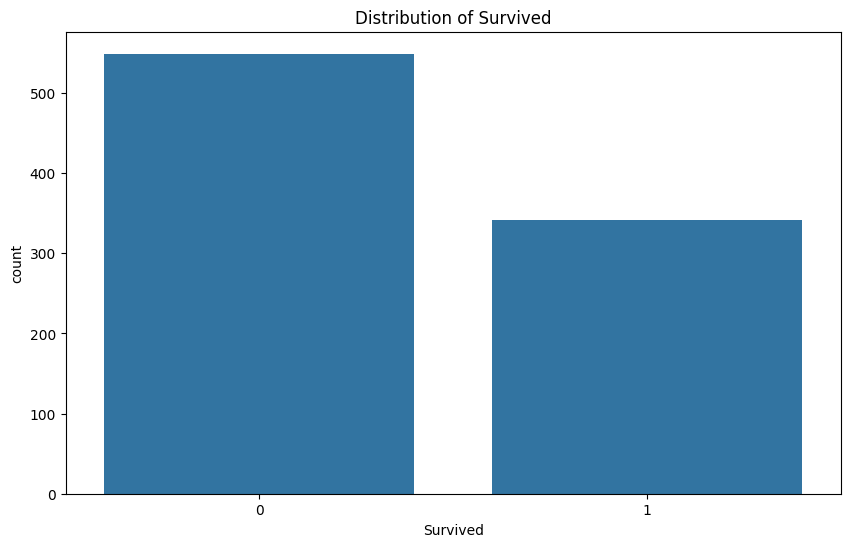

In [78]:
plt.figure(figsize=(10,6))
sns.countplot(x='Survived',data=df)
plt.title('Distribution of Survived')
plt.show()

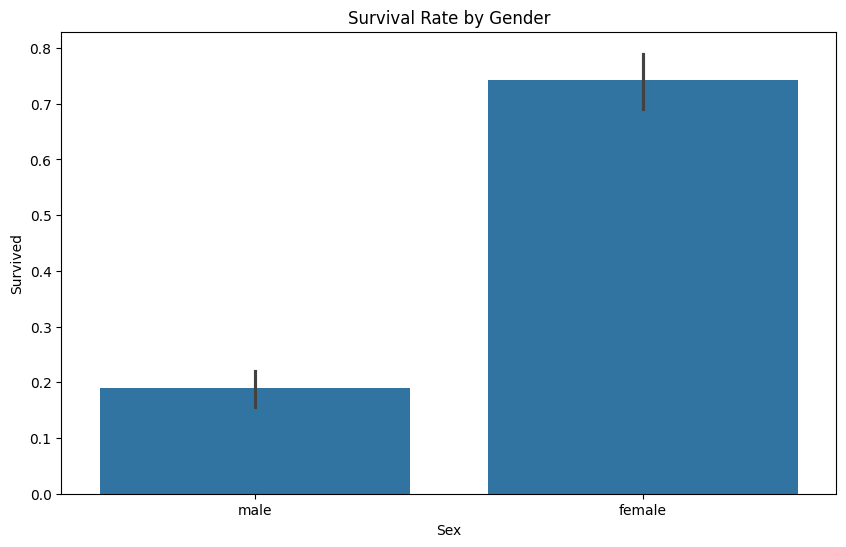

In [79]:
plt.figure(figsize=(10,6))
sns.barplot(x="Sex",y="Survived",data=df)
plt.title('Survival Rate by Gender')
plt.show()

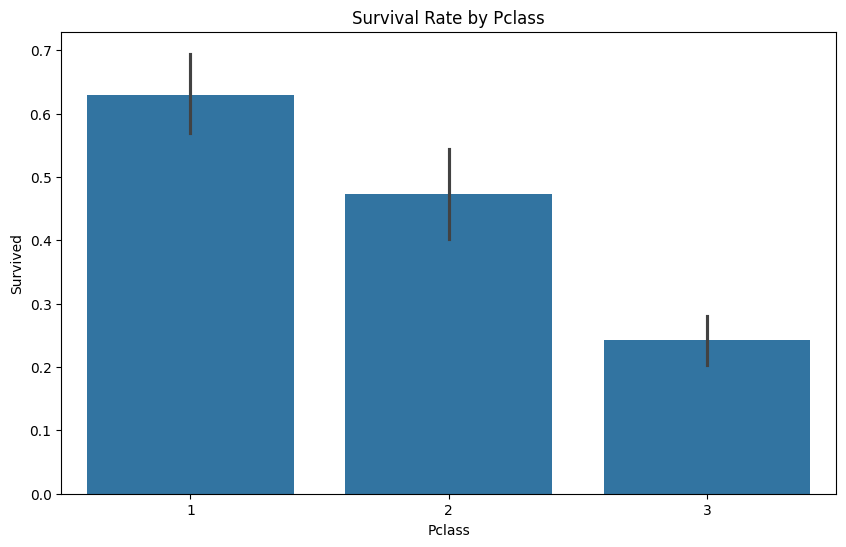

In [80]:
plt.figure(figsize=(10,6))
sns.barplot(x='Pclass',y='Survived',data=df)
plt.title('Survival Rate by Pclass')
plt.show()

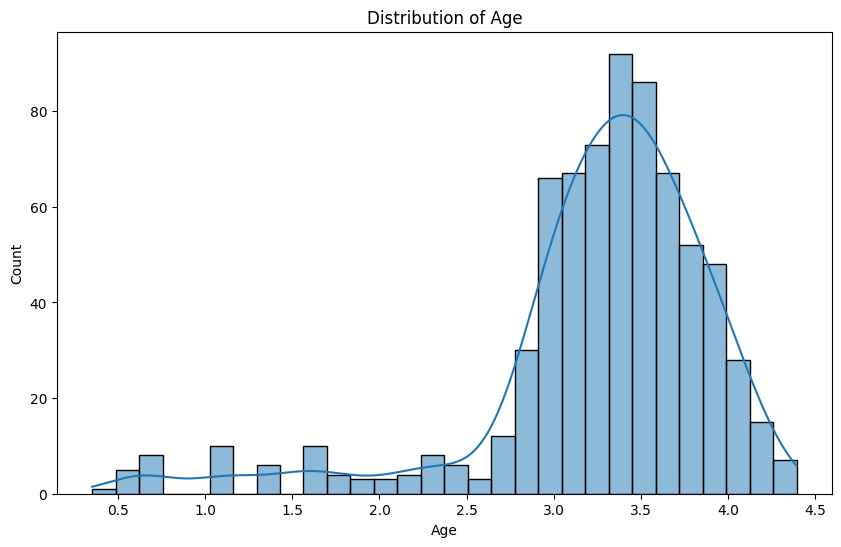

In [81]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['Age']),bins=30,kde=True)
plt.title('Distribution of Age')
plt.show()

max preprocessing and feature engineering 

In [82]:
df['Title']=df["Name"].str.extract(' ([A-Za-z]+)\.',expand=False)
df['Title'].value_counts()
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/var/folders/79/qf4s258d1979pqm6v_z63bmc0000gn/T/ipykernel_1533/3781505064.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title']=df["Name"].str.extract(' ([A-Za-z]+)\.',expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [83]:
rare_titles=['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
df['Title']=df['Title'].replace(rare_titles,'Rare')
df['Title']=df['Title'].replace(['Mlle','Ms'],'Miss')
df['Title']=df['Title'].replace('Mme','Mrs')
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

family features

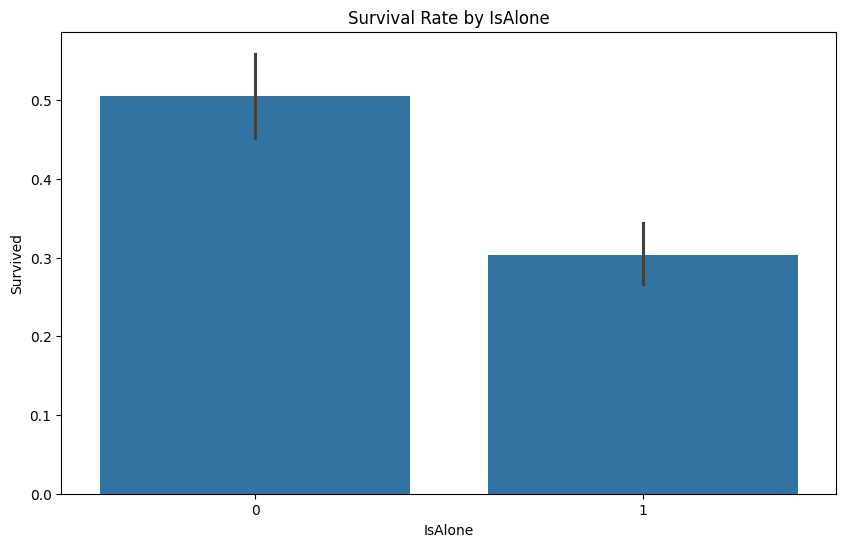

In [84]:
df['FamilySize']=df['SibSp']+df['Parch']+1
df['IsAlone']=df['FamilySize'].apply(lambda x: 1 if x==1 else 0)
plt.figure(figsize=(10,6))
sns.barplot(x='IsAlone',y='Survived',data=df)
plt.title('Survival Rate by IsAlone')
plt.show()

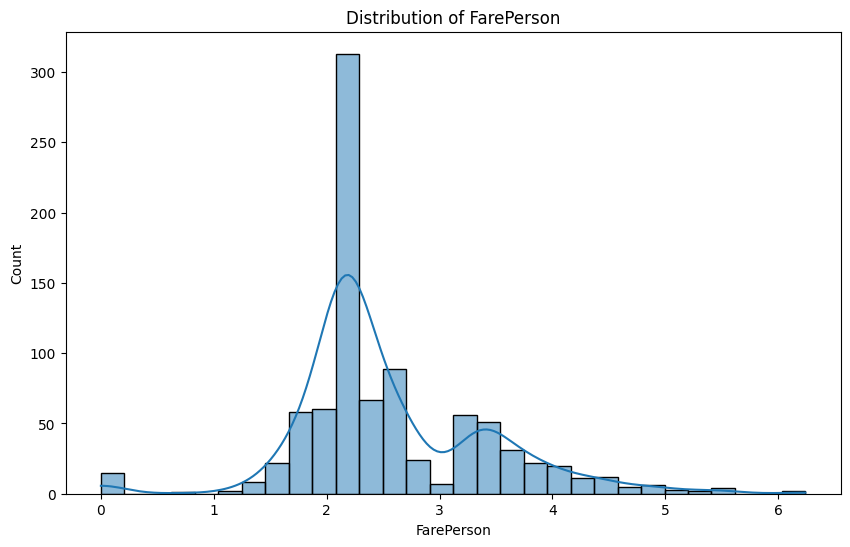

In [85]:
df['FarePerson']=df['Fare']/(df['FamilySize'])
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['FarePerson']),bins=30,kde=True)
plt.title('Distribution of FarePerson')
plt.show()

In [86]:
df["LogFare"]=np.log1p(df['Fare'])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,3.62500,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,35.64165,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,7.92500,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,26.55000,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,8.05000,2.202765


In [87]:
df['AgeGroup']=df.groupby("Title")['Age'].transform(lambda x: x.fillna(x.median()))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,3.62500,2.110213,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,35.64165,4.280593,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,7.92500,2.188856,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,26.55000,3.990834,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,8.05000,2.202765,35.0


In [88]:
df['AgeGroup']=pd.cut(df['Age'],bins=[0,12,18,35,60,80],labels=['Child','Teenager','Adult','MiddleAged','Senior'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,3.62500,2.110213,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,35.64165,4.280593,MiddleAged
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,7.92500,2.188856,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,26.55000,3.990834,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,8.05000,2.202765,Adult


In [89]:
df["cabin"]=df['Cabin'].fillna("U")
df["Deck"]=df["cabin"].str[0]
df["Deck"].value_counts()

Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [90]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])


In [91]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FarePerson,LogFare,AgeGroup,cabin,Deck
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,3.62500,2.110213,Adult,U,U
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,35.64165,4.280593,MiddleAged,C85,C
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,7.92500,2.188856,Adult,U,U
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,26.55000,3.990834,Adult,C123,C
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,8.05000,2.202765,Adult,U,U


final dataset preparation 

In [92]:
x=df.drop('Survived',axis=1)
y=df['Survived']
cat_cols=x.select_dtypes(include=['object','category']).columns.tolist()
cat_idx=[x.columns.get_loc(col) for col in cat_cols]
cat_cols

['Sex', 'Embarked', 'Title', 'AgeGroup', 'cabin', 'Deck']

In [93]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [94]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_auc,cv_acc=[],[]

cat_cols_train=x_train.select_dtypes(include=['object','category']).columns.tolist()
cat_idx_train=[x_train.columns.get_loc(col) for col in cat_cols_train]

for fold,(tr_idx,val_idx) in enumerate(skf.split(x_train,y_train)):
    x_tr,x_val=x_train.iloc[tr_idx].copy(),x_train.iloc[val_idx].copy()
    y_tr,y_val=y_train.iloc[tr_idx],y_train.iloc[val_idx]

    # CatBoost requires categorical features to be string/int (no raw NaN floats).
    x_tr[cat_cols_train]=x_tr[cat_cols_train].astype('object').where(x_tr[cat_cols_train].notna(),'Missing').astype(str)
    x_val[cat_cols_train]=x_val[cat_cols_train].astype('object').where(x_val[cat_cols_train].notna(),'Missing').astype(str)

    model=CatBoostClassifier(iterations=900,learning_rate=0.05,depth=6,l2_leaf_reg=2,random_strength=1,loss_function='Logloss',eval_metric='AUC',verbose=0)
    model.fit(
        x_tr,y_tr,
        cat_features=cat_idx_train,
        eval_set=[(x_val,y_val)],
        early_stopping_rounds=100,
        verbose=100
    )
    val_pred=model.predict(x_val)
    val_proba=model.predict_proba(x_val)[:,1]
    cv_auc.append(roc_auc_score(y_val,val_proba))

    cv_acc.append(accuracy_score(y_val,val_pred))
    print(f'Fold {fold+1} - AUC: {cv_auc[-1]:.4f}, Accuracy: {cv_acc[-1]:.4f}')
print(f'CV AUC: {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'CV Accuracy: {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}')


0:	test: 0.8361570	best: 0.8361570 (0)	total: 2.61ms	remaining: 2.35s
100:	test: 0.8770661	best: 0.8861570 (7)	total: 186ms	remaining: 1.47s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8861570248
bestIteration = 7

Shrink model to first 8 iterations.
Fold 1 - AUC: 0.8862, Accuracy: 0.8112
0:	test: 0.7883264	best: 0.7883264 (0)	total: 3.05ms	remaining: 2.74s
100:	test: 0.8458678	best: 0.8475207 (75)	total: 194ms	remaining: 1.54s
200:	test: 0.8535124	best: 0.8535124 (200)	total: 385ms	remaining: 1.34s
300:	test: 0.8516529	best: 0.8574380 (260)	total: 579ms	remaining: 1.15s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8574380165
bestIteration = 260

Shrink model to first 261 iterations.
Fold 2 - AUC: 0.8574, Accuracy: 0.8042
0:	test: 0.8660397	best: 0.8660397 (0)	total: 1.63ms	remaining: 1.46s
100:	test: 0.9233020	best: 0.9237200 (91)	total: 194ms	remaining: 1.53s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.92371995

In [95]:
x_train_final=x_train.copy()
cat_cols_final=x_train_final.select_dtypes(include=['object','category']).columns.tolist()
cat_idx_final=[x_train_final.columns.get_loc(col) for col in cat_cols_final]
x_train_final[cat_cols_final]=x_train_final[cat_cols_final].astype('object').where(x_train_final[cat_cols_final].notna(),'Missing').astype(str)

final_model=CatBoostClassifier(iterations=900,learning_rate=0.05,depth=6,l2_leaf_reg=2,random_strength=1,loss_function='Logloss',eval_metric='AUC',verbose=0)
final_model.fit(
    x_train_final,y_train,cat_features=cat_idx_final
)


In [96]:
x_test_final=x_test.copy()
cat_cols_model=[x_test_final.columns[i] for i in final_model.get_cat_feature_indices()]
x_test_final[cat_cols_model]=x_test_final[cat_cols_model].astype('object').where(x_test_final[cat_cols_model].notna(),'Missing').astype(str)

test_proba=final_model.predict_proba(x_test_final)[:,1]
best_threshold=0.515
test_pred=(test_proba>=best_threshold).astype(int)
print(f"Final test AUC: {roc_auc_score(y_test,test_proba):.4f}, Accuracy: {accuracy_score(y_test,test_pred):.4f}, Threshold: {best_threshold}")


Final test AUC: 0.8232, Accuracy: 0.8212, Threshold: 0.515


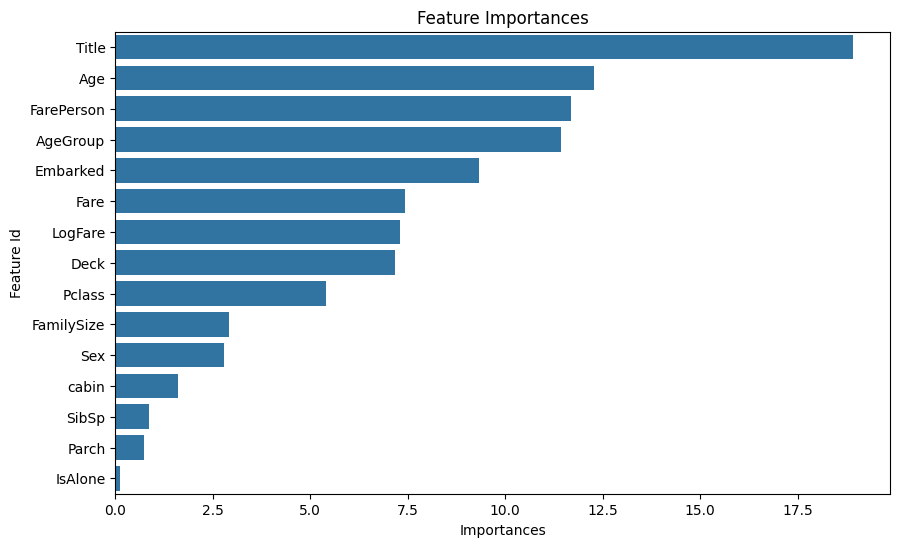

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
imp=final_model.get_feature_importance(prettified=True)
order=np.argsort(imp['Importances'])
plt.figure(figsize=(10,6))
sns.barplot(x=imp['Importances'],y=imp['Feature Id'].iloc[order])
plt.title('Feature Importances')
plt.show()

get validation propabilities 

In [99]:
from sklearn.model_selection import train_test_split
x_tr,x_val,y_tr,y_val=train_test_split(
    x_train,y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)
model=CatBoostClassifier(
    iterations=3000,
    depth=7,
    learning_rate=0.02,
    l2_leaf_reg=3,

    loss_function='Logloss',
    eval_metric='AUC',
    verbose=100,
    random_state=42
)

In [100]:
x_tr_last=x_tr.copy()
x_val_last=x_val.copy()
cat_cols_last=x_tr_last.select_dtypes(include=['object','category']).columns.tolist()
cat_idx_last=[x_tr_last.columns.get_loc(col) for col in cat_cols_last]

x_tr_last[cat_cols_last]=x_tr_last[cat_cols_last].astype('object').where(x_tr_last[cat_cols_last].notna(),'Missing').astype(str)
x_val_last[cat_cols_last]=x_val_last[cat_cols_last].astype('object').where(x_val_last[cat_cols_last].notna(),'Missing').astype(str)

model.fit(
    x_tr_last,y_tr,
    cat_features=cat_idx_last,
    eval_set=[(x_val_last,y_val)],
    early_stopping_rounds=200,
    verbose=100
)


0:	test: 0.8676653	best: 0.8676653 (0)	total: 1.59ms	remaining: 4.76s
100:	test: 0.8668388	best: 0.8857438 (25)	total: 280ms	remaining: 8.03s
200:	test: 0.8644628	best: 0.8857438 (25)	total: 558ms	remaining: 7.77s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8857438017
bestIteration = 25

Shrink model to first 26 iterations.


In [101]:
thresholds=np.arange(0.1,0.91,0.001)
best_threshold=0.5
best_auc=0

accuracy_scores=[]
for thresh in thresholds:
    val_pred_thresh=(model.predict_proba(x_val_last)[:,1]>=thresh).astype(int)
    acc=accuracy_score(y_val,val_pred_thresh)
    accuracy_scores.append(acc)
    if acc>best_auc:
        best_auc=acc
        best_threshold=thresh  
print(f'Best Threshold: {best_threshold:.3f}, Best Accuracy: {best_auc:.4f}')

Best Threshold: 0.472, Best Accuracy: 0.8462


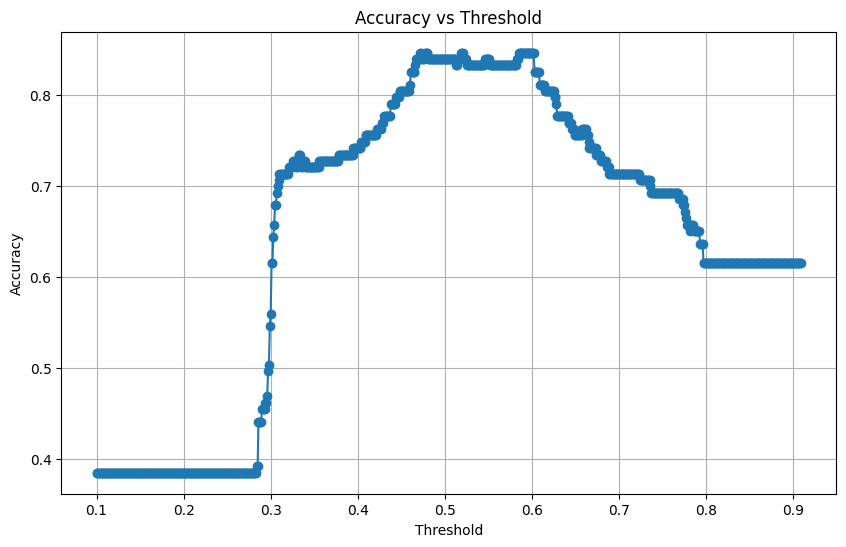

In [102]:
plt.figure(figsize=(10,6))
plt.plot(thresholds,accuracy_scores,marker='o')
plt.title('Accuracy vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [103]:
final_model.fit(
    x_train_final,y_train,
    cat_features=cat_idx_final,
    eval_set=[(x_val_last,y_val)],
    early_stopping_rounds=200,
    verbose=100
)

0:	test: 0.8297521	best: 0.8297521 (0)	total: 2.38ms	remaining: 2.14s
100:	test: 0.9247934	best: 0.9262397 (93)	total: 198ms	remaining: 1.56s
200:	test: 0.9430785	best: 0.9439050 (199)	total: 389ms	remaining: 1.35s
300:	test: 0.9548554	best: 0.9548554 (300)	total: 601ms	remaining: 1.2s
400:	test: 0.9660124	best: 0.9666322 (391)	total: 805ms	remaining: 1s
500:	test: 0.9699380	best: 0.9701446 (490)	total: 1.07s	remaining: 854ms
600:	test: 0.9724174	best: 0.9726240 (598)	total: 1.27s	remaining: 634ms
700:	test: 0.9744835	best: 0.9755165 (674)	total: 1.48s	remaining: 419ms
800:	test: 0.9748967	best: 0.9755165 (674)	total: 1.68s	remaining: 208ms
899:	test: 0.9769628	best: 0.9769628 (896)	total: 1.88s	remaining: 0us

bestTest = 0.9769628099
bestIteration = 896

Shrink model to first 897 iterations.


In [105]:
x_test_eval=x_test.copy()
cat_cols_model=[x_test_eval.columns[i] for i in model.get_cat_feature_indices()]
x_test_eval[cat_cols_model]=x_test_eval[cat_cols_model].astype('object').where(x_test_eval[cat_cols_model].notna(),'Missing').astype(str)

test_proba=model.predict_proba(x_test_eval)[:,1]
test_preds_custom=(test_proba>=best_threshold).astype(int)
print(f"Final test AUC: {roc_auc_score(y_test,test_proba):.4f}, Accuracy: {accuracy_score(y_test,test_preds_custom):.4f}, Threshold: {best_threshold:.3f}")


Final test AUC: 0.8590, Accuracy: 0.8212, Threshold: 0.472


5 fold cv

In [109]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
threshold_grid=np.arange(0.1,0.91,0.01)

fold_best_thresholds=[]
fold_best_accuracies=[]

find the best threshold per fold 

In [110]:
for fold,(tr_idx,val_idx) in enumerate(skf.split(x_train,y_train)):
    x_tr,x_val=x_train.iloc[tr_idx].copy(),x_train.iloc[val_idx].copy()
    y_tr,y_val=y_train.iloc[tr_idx],y_train.iloc[val_idx]

    cat_cols_fold=x_tr.select_dtypes(include=['object','category']).columns.tolist()
    cat_idx_fold=[x_tr.columns.get_loc(col) for col in cat_cols_fold]
    x_tr[cat_cols_fold]=x_tr[cat_cols_fold].astype('object').where(x_tr[cat_cols_fold].notna(),'Missing').astype(str)
    x_val[cat_cols_fold]=x_val[cat_cols_fold].astype('object').where(x_val[cat_cols_fold].notna(),'Missing').astype(str)

    model=CatBoostClassifier(iterations=3000,learning_rate=0.02,depth=6,l2_leaf_reg=2,random_strength=1,loss_function='Logloss',eval_metric='AUC',verbose=0)
    model.fit(
        x_tr,y_tr,
        cat_features=cat_idx_fold
    )
    val_proba=model.predict_proba(x_val)[:,1]
    best_fold_acc=0
    best_fold_threshold=0.5
    for thresh in threshold_grid:
        val_pred_thresh=(val_proba>=thresh).astype(int)
        acc=accuracy_score(y_val,val_pred_thresh)
        if acc>best_fold_acc:
            best_fold_acc=acc
            best_fold_threshold=thresh
    fold_best_accuracies.append(best_fold_acc)
    fold_best_thresholds.append(best_fold_threshold)
    print(f'Fold {fold+1} - Best Threshold: {best_fold_threshold:.2f}, Accuracy: {best_fold_acc:.4f}')


Fold 1 - Best Threshold: 0.65, Accuracy: 0.8671
Fold 2 - Best Threshold: 0.82, Accuracy: 0.8112
Fold 3 - Best Threshold: 0.24, Accuracy: 0.8873
Fold 4 - Best Threshold: 0.40, Accuracy: 0.8380
Fold 5 - Best Threshold: 0.49, Accuracy: 0.8592


In [111]:
final_threshold=np.mean(fold_best_thresholds)
print(f'Average Optimal Threshold across folds: {final_threshold:.2f}') 
print(f'Average Accuracy at Optimal Threshold: {np.mean(fold_best_accuracies):.4f} ± {np.std(fold_best_accuracies):.4f}')

Average Optimal Threshold across folds: 0.52
Average Accuracy at Optimal Threshold: 0.8526 ± 0.0260


In [112]:
final_model=CatBoostClassifier(iterations=3000,learning_rate=0.02,depth=7,l2_leaf_reg=3,random_strength=1,loss_function='Logloss',verbose=0)
final_model.fit(
    x_train_final,y_train,cat_features=cat_idx_final
)

In [113]:
test_proba=final_model.predict_proba(x_test_final)[:,1]
default_preds=(test_proba>=0.5).astype(int)
custom_preds=(test_proba>=final_threshold).astype(int)
print(f"Default Threshold (0.5) - AUC: {roc_auc_score(y_test,test_proba):.4f}, Accuracy: {accuracy_score(y_test,default_preds):.4f}")
print(f"Custom Threshold ({final_threshold:.2f}) - AUC: {roc_auc_score(y_test,test_proba):.4f}, Accuracy: {accuracy_score(y_test,custom_preds):.4f}")

Default Threshold (0.5) - AUC: 0.8333, Accuracy: 0.8212
Custom Threshold (0.52) - AUC: 0.8333, Accuracy: 0.8212


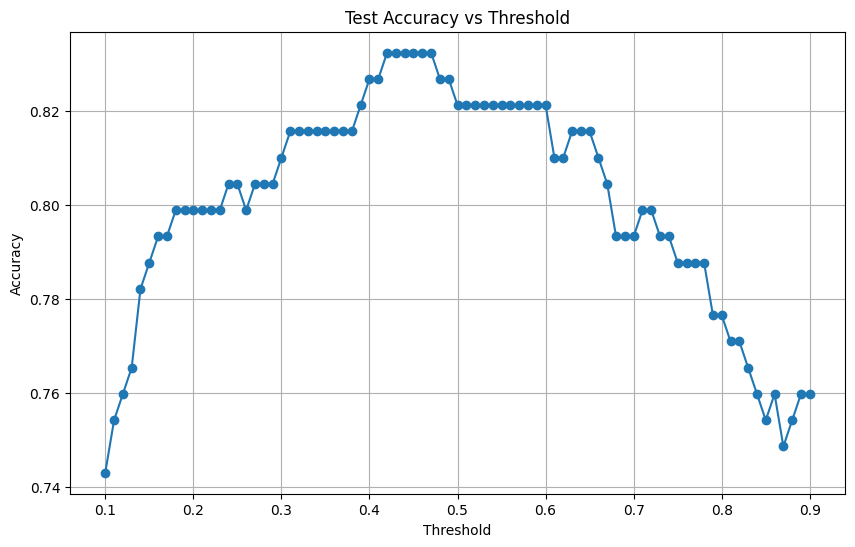

In [114]:
test_accuracies=[]
for thresh in threshold_grid:
    test_pred_thresh=(test_proba>=thresh).astype(int)
    acc=accuracy_score(y_test,test_pred_thresh)
    test_accuracies.append(acc)
plt.figure(figsize=(10,6))
plt.plot(threshold_grid,test_accuracies,marker='o')
plt.title('Test Accuracy vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.grid()

OOF prediction 

In [116]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,roc_auc_score    
import numpy as np

In [117]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
oof_preds=np.zeros(len(x_train))
test_best_folds=[]
threshold_grid=np.arange(0.1,0.91,0.01)

In [118]:
for fold,(tr_idx,val_idx) in enumerate(skf.split(x_train,y_train)): 
    x_tr,x_val=x_train.iloc[tr_idx].copy(),x_train.iloc[val_idx].copy()
    y_tr,y_val=y_train.iloc[tr_idx],y_train.iloc[val_idx]

    cat_cols_fold=x_tr.select_dtypes(include=['object','category']).columns.tolist()
    cat_idx_fold=[x_tr.columns.get_loc(col) for col in cat_cols_fold]
    x_tr[cat_cols_fold]=x_tr[cat_cols_fold].astype('object').where(x_tr[cat_cols_fold].notna(),'Missing').astype(str)
    x_val[cat_cols_fold]=x_val[cat_cols_fold].astype('object').where(x_val[cat_cols_fold].notna(),'Missing').astype(str)

    model=CatBoostClassifier(iterations=3000,learning_rate=0.02,depth=6,l2_leaf_reg=2,random_strength=1,loss_function='Logloss',eval_metric='AUC',verbose=0)
    model.fit(
        x_tr,y_tr,
        cat_features=cat_idx_fold
    )
    val_proba=model.predict_proba(x_val)[:,1]
    best_fold_acc=0
    best_fold_threshold=0.5
    for thresh in threshold_grid:
        val_pred_thresh=(val_proba>=thresh).astype(int)
        acc=accuracy_score(y_val,val_pred_thresh)
        if acc>best_fold_acc:
            best_fold_acc=acc
            best_fold_threshold=thresh
    fold_best_accuracies.append(best_fold_acc)
    fold_best_thresholds.append(best_fold_threshold)
    print(f'Fold {fold+1} - Best Threshold: {best_fold_threshold:.2f}, Accuracy: {best_fold_acc:.4f}')

Fold 1 - Best Threshold: 0.65, Accuracy: 0.8671
Fold 2 - Best Threshold: 0.82, Accuracy: 0.8112
Fold 3 - Best Threshold: 0.24, Accuracy: 0.8873
Fold 4 - Best Threshold: 0.40, Accuracy: 0.8380
Fold 5 - Best Threshold: 0.49, Accuracy: 0.8592


In [119]:
print("OOF_AUC: {:.4f}".format(roc_auc_score(y_train,oof_preds)))

OOF_AUC: 0.5000


stacking

level 2 model 

In [121]:
x_stack_train=({
    "catboost_oof": oof_preds
})
x_stack_test=({
    "catboost_oof":np.mean(test_proba,axis=0)  
    })# Using mean test probability across folds for stacking

In [122]:
from sklearn.linear_model import LogisticRegression
meta_model=LogisticRegression()
meta_model.fit(x_stack_train,y_train)
meta_test_proba=meta_model.predict_proba(x_stack_test)[:,1]
print(f"Meta-model Test AUC: {roc_auc_score(y_test,meta_test_proba):.4f}")

TypeError: float() argument must be a string or a real number, not 'dict'